In [13]:
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def generate_latent_points(latent_dim,n_samples):
    # generate points in the latent space
    x_input = np.random.randn(latent_dim*n_samples)
    # reshape
    x_input = x_input.reshape(n_samples,latent_dim)
    
    return x_input

def generate_fake_samples(g_model,latent_dim,n_samples):
    # generate points in latent space
    x_input = generate_latent_points(latent_dim,n_samples)
    # predict outputs
    X = g_model.predict(x_input)
    # create 'fake' class labels (0)
    y = np.zeros((n_samples,1))
    return X,y
# output_ = (1,224,224,3)
def recovery(output_):
    output_ = (output_ + 1)*127.5
    output_ = output_.astype(np.uint8)
    return output_


In [15]:
model = load_model('./generator_model_010.h5')
X = generate_fake_samples(model,100,1)

1/1 [==============================] - 0s 323ms/step


(1, 224, 224, 3)


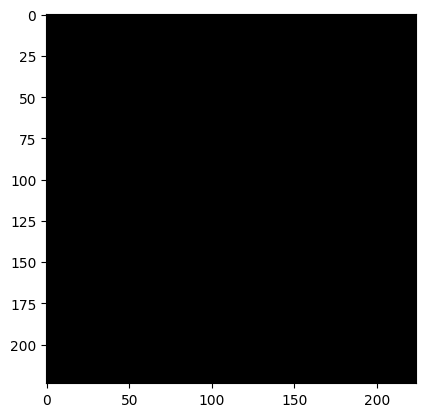

In [16]:
print(X[0].shape)
plt.imshow(recovery(X[0])[0])
plt.savefig('./fake/recovery_image.png')